In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Doctorado/Set de Datos 2/Objetivo 4/4_Integracion y Benn/Compuestos_Comunes_modelos.csv')

In [ ]:
df

,Name,SMILES,Total Molweight,cLogP,H-Acceptors,H-Donors,Total Surface Area,Relative PSA,Rotatable Bonds,Senotherapeutics:
0,(19Z)-halichondramide,CC1CCC=CC2=NC(=CO2)C3=NC(=CO3)C4=NC(=CO4)C(C(C...,836.976,5.0626,16,1,674.23,0.27298,14,1
1,(4-(((2-(3-fluoro-4-(trifluoromethyl)phenyl)-4...,CC1=C(C=CC(=C1)SCC2=C(N=C(S2)C3=CC(=C(C=C3)C(F...,471.494,5.1092,4,1,326.92,0.25988,8,1
2,"(5-(2,4-bis((3S)-3-methylmorpholin-4-yl)pyrido...",CC1COCCN1C2=NC(=NC3=C2C=CC(=N3)C4=CC(=C(C=C4)O...,465.552,2.4865,9,1,351.95,0.23614,5,1
3,(E)-4-((2-N-(4-methoxybenzenesulfonyl)amino)st...,COC1=CC=C(C=C1)S(=O)(=O)N=C2C=CC=CC2=CC=C3C=CN...,382.439,1.7590,6,1,292.14,0.22845,3,1
4,"1,2-distearoyllecithin",CCCCCCCCCCCCCCCCCC(=O)OCC(COP(=O)([O-])OCC[N+]...,790.156,7.7767,9,0,695.34,0.12909,44,1
...,...,...,...,...,...,...,...,...,...,...
709,zinc protoporphyrin,CC1=C(C2=CC3=NC(=CC4=C(C(=C([N-]4)C=C5C(=C(C(=...,626.042,5.1545,8,4,435.19,0.23151,8,1
710,ziyuglycoside I,CC1CCC2(CCC3(C(=CCC4C3(CCC5C4(CCC(C5(C)C)OC6C(...,766.962,2.1065,13,8,526.90,0.29956,6,1
711,ziyuglycoside II,CC1CCC2(CCC3(C(=CCC4C3(CCC5C4(CCC(C5(C)C)OC6C(...,604.822,3.9436,8,5,425.09,0.23181,3,1
712,zomepirac glucuronide,CC1=C(N(C(=C1)CC(=O)OC2C(C(C(C(O2)C(=O)O)O)O)O...,467.857,-0.0007,10,4,323.57,0.36589,7,1


# BUSCAR UN PAPER DONDE INDIQUE LOS PARAMETROS REPORTADOS PARA LOS LEADLIKENESS

Ajustarr los parametros de Leadlikeness a

Peso molecular <=300

cLogP <=3

Aceptores de puestes de hidrogeno <=3

Donadores de puestes de hidrogeno <=3

Enlaces rotables <=8

In [ ]:
import pandas as pd

# Definir los valores de Leadlikeness
def is_Leadlikeness(row):
    mw_condition = 1 <= row['Total Molweight'] <= 500
    clogp_condition = row['cLogP'] <= 5
    h_acceptors_condition = row['H-Acceptors'] <= 10
    h_donors_condition = row['H-Donors'] <= 5
    rotatable_bonds_condition = row['Rotatable Bonds'] <= 8

    return mw_condition and clogp_condition and h_acceptors_condition and h_donors_condition and rotatable_bonds_condition

# Crear una nueva columna en el dataframe indicando si la molecula cumple con los parametros de leadlikeness o no los cumple
df['Leadlikeness'] = df.apply(is_Leadlikeness, axis=1)

# Mostrar los primeros resultados
print(df[['Name', 'Leadlikeness']])


                                                  Name  Leadlikeness
0                                (19Z)-halichondramide         False
1    (4-(((2-(3-fluoro-4-(trifluoromethyl)phenyl)-4...         False
2    (5-(2,4-bis((3S)-3-methylmorpholin-4-yl)pyrido...          True
3    (E)-4-((2-N-(4-methoxybenzenesulfonyl)amino)st...          True
4                               1,2-distearoyllecithin         False
..                                                 ...           ...
709                                zinc protoporphyrin         False
710                                    ziyuglycoside I         False
711                                   ziyuglycoside II         False
712                              zomepirac glucuronide          True
713                                        zopolrestat          True

[714 rows x 2 columns]


Indicar que muestre los valores verdaderos

In [ ]:
# Muestrame los valores verdaderos

# Filtrar el DataFrame para obtener solo las filas con 'Lead-like' == True
Leadlikeness_compounds = df[df['Leadlikeness'] == True]

# Mostrar los resultados
print(Leadlikeness_compounds[['Name', 'Leadlikeness']])


                                                  Name  Leadlikeness
2    (5-(2,4-bis((3S)-3-methylmorpholin-4-yl)pyrido...          True
3    (E)-4-((2-N-(4-methoxybenzenesulfonyl)amino)st...          True
7                            10-decarbamoylmitomycin C          True
8                               10-hydroxycamptothecin          True
9                                               103D5R          True
..                                                 ...           ...
700                                        vistusertib          True
703                                       withaferin A          True
704                                          withanone          True
712                              zomepirac glucuronide          True
713                                        zopolrestat          True

[270 rows x 2 columns]


In [ ]:
Leadlikeness_compounds

,Name,SMILES,Total Molweight,cLogP,H-Acceptors,H-Donors,Total Surface Area,Relative PSA,Rotatable Bonds,Senotherapeutics:,Leadlikeness
2,"(5-(2,4-bis((3S)-3-methylmorpholin-4-yl)pyrido...",CC1COCCN1C2=NC(=NC3=C2C=CC(=N3)C4=CC(=C(C=C4)O...,465.552,2.4865,9,1,351.95,0.23614,5,1,True
3,(E)-4-((2-N-(4-methoxybenzenesulfonyl)amino)st...,COC1=CC=C(C=C1)S(=O)(=O)N=C2C=CC=CC2=CC=C3C=CN...,382.439,1.7590,6,1,292.14,0.22845,3,1,True
7,10-decarbamoylmitomycin C,CC1=C(C(=O)C2=C(C1=O)N3CC4C(C3(C2CO)OC)N4)N,291.306,-1.6656,7,3,197.58,0.45359,2,1,True
8,10-hydroxycamptothecin,CCC1(C2=C(COC1=O)C(=O)N3CC4=C(C3=C2)N=C5C=CC(=...,364.356,0.8381,7,2,246.20,0.31194,1,1,True
9,103D5R,CC(C1=C(C2=C(C=C1)OC(C=C2)(C)C)OC)N3C=NC4=C3C=...,335.406,4.0763,5,0,259.29,0.18824,3,1,True
...,...,...,...,...,...,...,...,...,...,...,...
700,vistusertib,CC1COCCN1C2=NC(=NC3=C2C=CC(=N3)C4=CC(=CC=C4)C(...,462.552,2.5926,9,1,351.05,0.24073,4,1,True
703,withaferin A,CC1=C(C(=O)OC(C1)C(C)C2CCC3C2(CCC4C3CC5C6(C4(C...,470.604,2.4938,6,2,334.36,0.23905,3,1,True
704,withanone,CC1=C(C(=O)OC(C1)C(C)C2(CCC3C2(CCC4C3C5C(O5)C6...,470.604,2.5971,6,2,330.77,0.24165,2,1,True
712,zomepirac glucuronide,CC1=C(N(C(=C1)CC(=O)OC2C(C(C(C(O2)C(=O)O)O)O)O...,467.857,-0.0007,10,4,323.57,0.36589,7,1,True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Guardar archic¿vo en scv
Leadlikeness_compounds.to_csv('/content/drive/MyDrive/Doctorado/Set de Datos 2/Objetivo 4/Leadlikeness_compounds.csv', index=False)

In [ ]:
# Seleccionar solo las columnas 'Name' y 'Smiles'
Leadlikeness_compounds_names_smiles = Leadlikeness_compounds[['Name', 'SMILES']]

# Mostrar el resultado
print(Leadlikeness_compounds_names_smiles)


                                                    Name  \
5                                     hex-2-ene-1,4-diol   
432    6,6,9a-trimethyl-1H,3H,5H,5aH,6H,7H,8H,9H,9aH,...   
627     2-ethyl-4-(hydroxymethyl)-2,3-dihydrofuran-3-one   
656                                   5-aminopentanamide   
658      1,2-dihydroxy-5-(methylsulfanyl)pent-1-en-3-one   
...                                                  ...   
51447                                3-pyridine aldoxime   
51460                            tris(methylthio)methane   
51488                                   stagonosporyne a   
51511                                          6890-37-5   
51537                                   stagonosporyne g   

                                  SMILES  
5                            OCC=CC(O)CC  
432    OC1OCC2=CCC3C(C)(C)C(O)CCC3(C)C21  
627                     O=C1C(=COC1CC)CO  
656                          O=C(N)CCCCN  
658                     O=C(C(O)=CO)CCSC  
...                  

In [ ]:
Leadlikeness_compounds_names_smiles.to_csv('Leadlikeness_smiles.csv', index=False)

# articulos que lo discuten

https://doi.org/10.1002/wcms.52
indica
MW.300 o menos
cLogP 3 o menos
HAC 10 o menos
HDO 5 o menos
RB 10 o menos


https://doi.org/10.1016/j.cbpa.2004.04.003
indica
MW.460 o menos
cLogP 4.2 o menos
HAC 9 o menos
HDO 5 o menos
RB 10 o menos



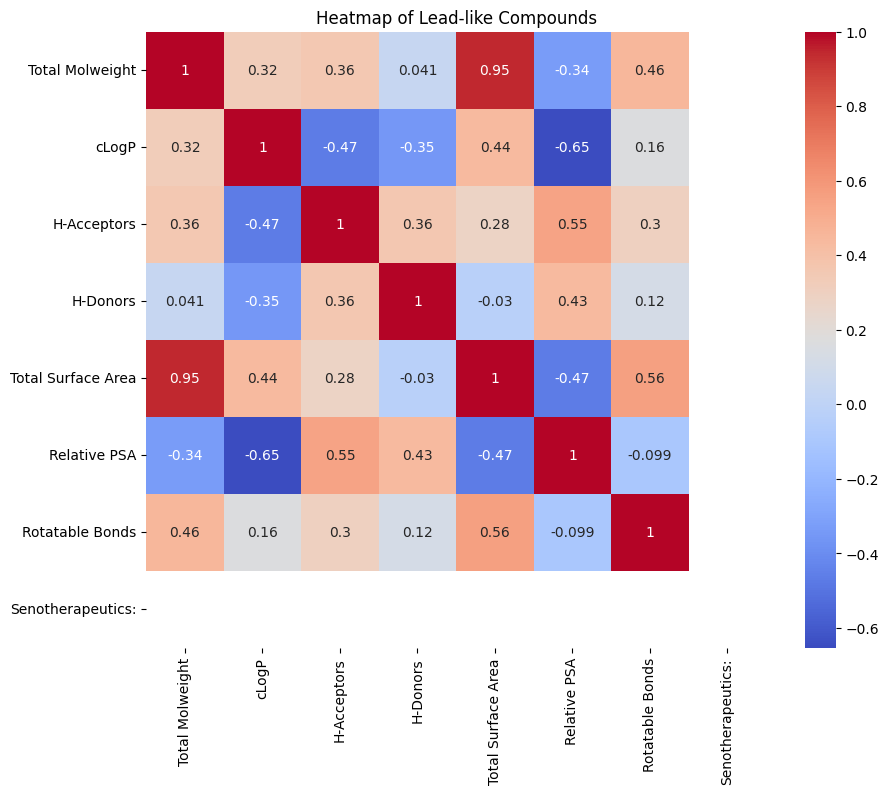

In [ ]:
# prompt: de esta data Leadlikeness_compounds quiero hacer un heatmap

import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'Leadlikeness_compounds' is your DataFrame
# Select numerical columns for the heatmap
numerical_columns = Leadlikeness_compounds.select_dtypes(include=['float', 'int']).columns

# Calculate the correlation matrix
correlation_matrix = Leadlikeness_compounds[numerical_columns].corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Heatmap of Lead-like Compounds')
plt.show()


In [ ]:
# prompt: de esta datafeame Leadlikeness_compounds que me suguieres hacer o analisar

import matplotlib.pyplot as plt
# Calculate descriptive statistics for numerical columns
descriptive_stats = Leadlikeness_compounds.describe()
print(descriptive_stats)

# Create histograms for numerical columns
for col in numerical_columns:
  plt.figure()
  sns.histplot(Leadlikeness_compounds[col], kde=True)
  plt.title(f'Distribution of {col}')
  plt.show()

# Create box plots for numerical columns to visualize outliers
for col in numerical_columns:
  plt.figure()
  sns.boxplot(y=Leadlikeness_compounds[col])
  plt.title(f'Box Plot of {col}')
  plt.show()

# Explore relationships between variables using scatter plots
for col1 in numerical_columns:
  for col2 in numerical_columns:
    if col1 != col2:
      plt.figure()
      sns.scatterplot(x=Leadlikeness_compounds[col1], y=Leadlikeness_compounds[col2])
      plt.title(f'{col1} vs {col2}')
      plt.show()


Output hidden; open in https://colab.research.google.com to view.